# Preparação de ambiente:

## Neste bloco estaremos instalando e importando as bibliotecas para fazemos nosso projeto


In [94]:
# Essas bibliotecas são necessárias para rodar o código do notebook. diferente do colab que já tem tudo instalado, no vscode é necessário instalar manualmente. Para isso, basta rodar o comando abaixo no terminal:
%pip install streamlit pandas numpy matplotlib seaborn scikit-learn joblib wordcloud

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
## Warning retirado, pois como nao estamos usando o colab, ele da warning de que o dataset é grande e pode causar problemas de memoria. como estamos usando um ambiente mais forte, podemos ignorar esse warning.

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, roc_curve, auc


sns.set_theme(style="whitegrid", palette="muted") # Tema elegante para gráficos
print("Carregando todo o dataset")


## Para pegar o dataset, basta clicar com o mouse em cima do arquivo, clicar com o botão direito e selecionar "Copy Path". Depois é só colar o caminho no código abaixo. Lembre-se de colocar o caminho entre aspas simples ou duplas.
df = pd.read_csv('../data/IMDB Dataset.csv', engine='python', on_bad_lines='skip')
print(f"Sucesso! Dataset carregado com {len(df)} reviews.")


Carregando todo o dataset
Sucesso! Dataset carregado com 50000 reviews.


## EDA antes de limparmos o dataset

In [96]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [97]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [98]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [99]:
## Verificando se há valores nulos no dataset. Se houver, é necessário tratá-los antes de prosseguir com a análise.
df.isna().any()

review       False
sentiment    False
dtype: bool

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


# Limpeza do dataSet:

## Antes de destrinchamos por completo o dataSet estaremos limpando ele.

In [101]:
# Função de limpeza (será usada nas próximas células)
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'<.*?>', ' ', texto) # Remove HTML
    texto = texto.translate(str.maketrans('', '', string.punctuation)) # Remove pontuação
    return texto

df['review_limpa'] = df['review'].apply(limpar_texto)
df['qtd_palavras'] = df['review_limpa'].apply(lambda x: len(x.split()))

In [102]:
df.rename(columns={'sentiment': 'sentimento'}, inplace=True)

In [103]:
df.head()

,review,sentimento,review_limpa,qtd_palavras
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,304
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming te...,156
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,164
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,132
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,225


In [104]:
df.tail()

,review,sentimento,review_limpa,qtd_palavras
49995,I thought this movie did a down right good job...,positive,i thought this movie did a down right good job...,192
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,bad plot bad dialogue bad acting idiotic direc...,110
49997,I am a Catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...,227
49998,I'm going to have to disagree with the previou...,negative,im going to have to disagree with the previous...,212
49999,No one expects the Star Trek movies to be high...,negative,no one expects the star trek movies to be high...,125


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review        50000 non-null  object
 1   sentimento    50000 non-null  object
 2   review_limpa  50000 non-null  object
 3   qtd_palavras  50000 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


In [106]:
print(f"Duplicatas encontradas: {df.duplicated().sum()}")  # 418
df.drop_duplicates(inplace=True)
print(f"Dataset após remoção: {len(df)} reviews")

Duplicatas encontradas: 418
Dataset após remoção: 49582 reviews


# EDA Pos limpaza de dados

Gráfico 1: Quantidade de Reviews por Sentimento


/var/folders/k9/4cr0z6g52v57c8vbddmtf_9w0000gn/T/ipykernel_9220/2238190306.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentimento', palette=['#4C72B0', '#C44E52'])


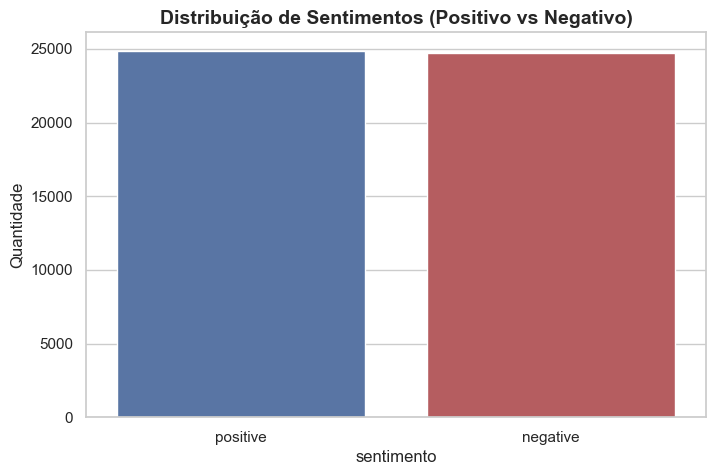

In [107]:
print("Gráfico 1: Quantidade de Reviews por Sentimento")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentimento', palette=['#4C72B0', '#C44E52'])
plt.title('Distribuição de Sentimentos (Positivo vs Negativo)', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade')
plt.show()

Gráfico 2: Qual o tamanho dos textos?


/var/folders/k9/4cr0z6g52v57c8vbddmtf_9w0000gn/T/ipykernel_9220/2615971069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentimento', y='qtd_palavras', palette=['#4C72B0', '#C44E52'])


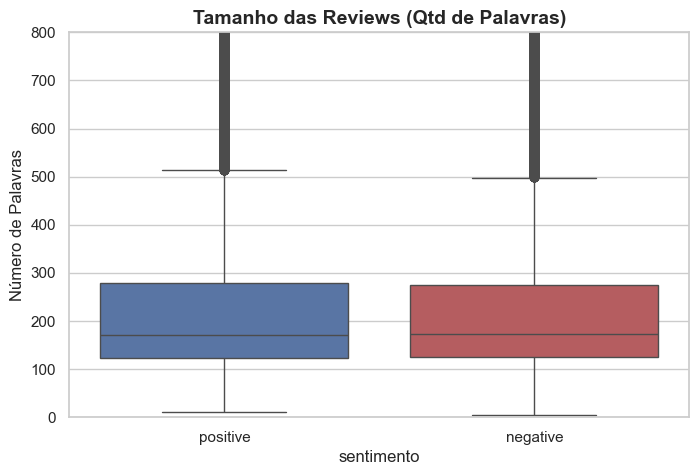

In [108]:
print("Gráfico 2: Qual o tamanho dos textos?")

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sentimento', y='qtd_palavras', palette=['#4C72B0', '#C44E52'])
plt.title('Tamanho das Reviews (Qtd de Palavras)', fontsize=14, fontweight='bold')
plt.ylim(0, 800) # Corta os textos absurdamente gigantes
plt.ylabel('Número de Palavras')
plt.show()

In [109]:
print("\nTamanho médio exato (em palavras):")

# Criando uma tabela para visualizar
tabela_tamanho = df.groupby('sentimento')['qtd_palavras'].mean().round(2).reset_index()
tabela_tamanho.columns = ['Sentimento', 'Média de Palavras'] # Renomeando as colunas para melhor visualização

display(tabela_tamanho)


Tamanho médio exato (em palavras):


,Sentimento,Média de Palavras
0,negative,226.30
1,positive,230.03


Gráficos 3 e 4: Nuvens de Palavras


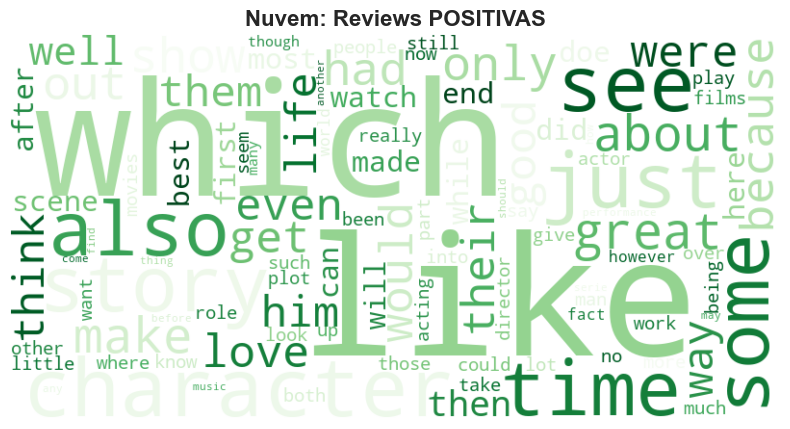

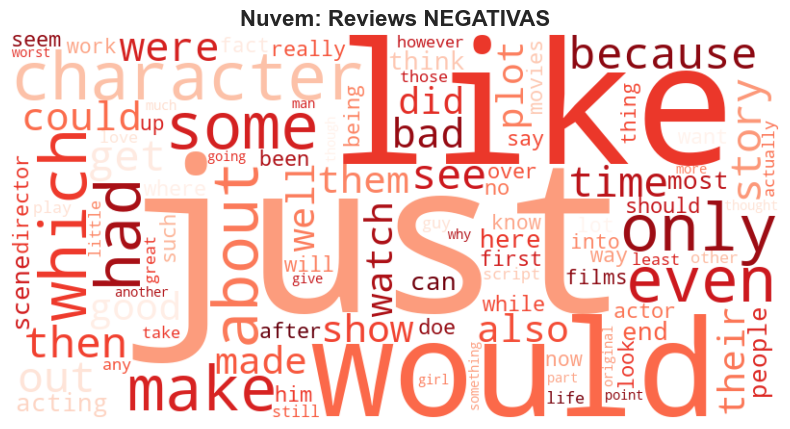

In [110]:
# Nuvem de palavras Eda
print("Gráficos 3 e 4: Nuvens de Palavras")

stopwords_lista = ['the', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this', 'that',
                   'was', 'as', 'for', 'with', 'movie', 'film', 'but', 'on', 'are', 'not',
                   'you', 'his', 'have', 'be', 'one', 'at', 'by', 'an', 'they', 'from', 'all', 
                   'its', 'he', 'she', 'we', 'my', 'me', 'do', 'if', 'or', 'what', 'who', 'when', 
                   'there', 'ha', 'her','so', 'has']

def gerar_nuvem(sentimento, titulo, colormap):
    reviews = " ".join(df[df['sentimento'] == sentimento]['review_limpa'])
    
    nuvem = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        colormap=colormap, 
        stopwords=stopwords_lista, 
        max_words=100
        ).generate(reviews)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(nuvem, interpolation='bilinear')
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

gerar_nuvem('positive', 'Nuvem: Reviews POSITIVAS', 'Greens_r')
gerar_nuvem('negative', 'Nuvem: Reviews NEGATIVAS', 'Reds_r')

# Inicio ao pré-processamento

Gráficos 5 e 6: Contexto (Duplas de Palavras)


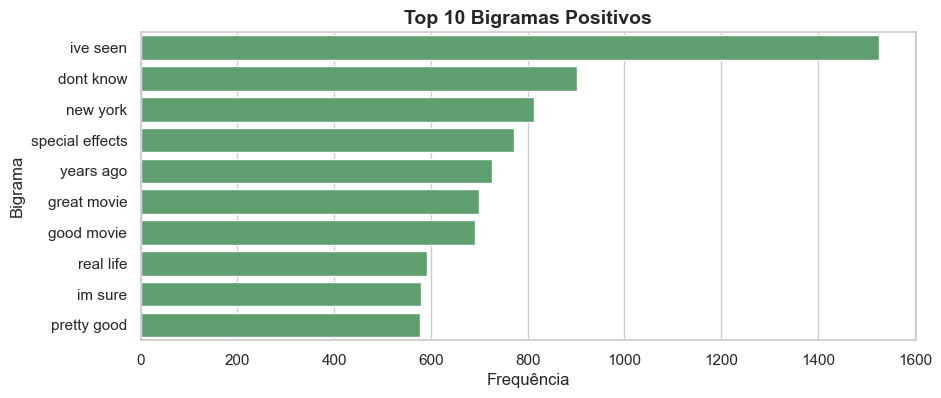

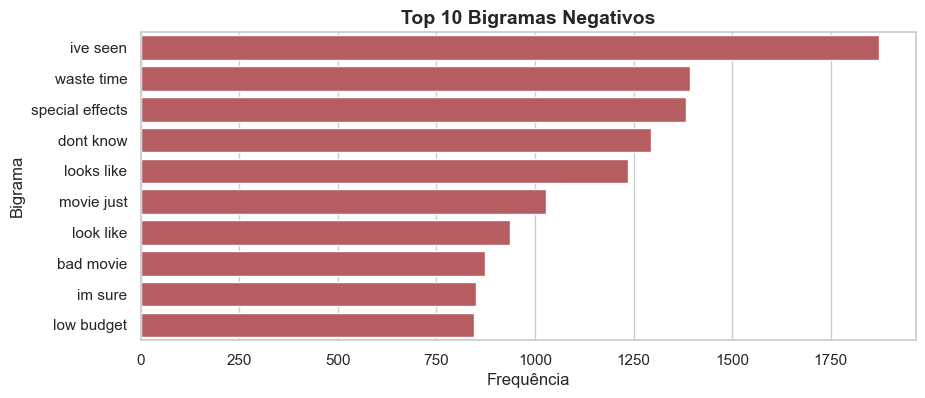

In [111]:
# Dupla de palavras
print("Gráficos 5 e 6: Contexto (Duplas de Palavras)")

def plotar_bigramas(sentimento, titulo, cor):
    textos = df[df['sentimento'] == sentimento]['review_limpa']
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10).fit(textos)
    bag_of_words = vec.transform(textos)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    plt.figure(figsize=(10, 4))
    sns.barplot(x='Frequência', y='Bigrama', data=pd.DataFrame(words_freq, columns=['Bigrama', 'Frequência']), color=cor)
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.show()

plotar_bigramas('positive', 'Top 10 Bigramas Positivos', '#55A868')
plotar_bigramas('negative', 'Top 10 Bigramas Negativos', '#C44E52')

Gráficos: Contexto Profundo (Tri-gramas)


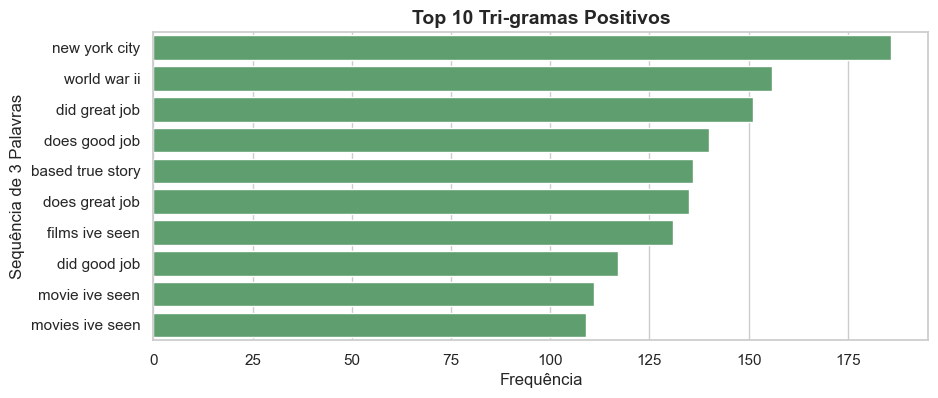

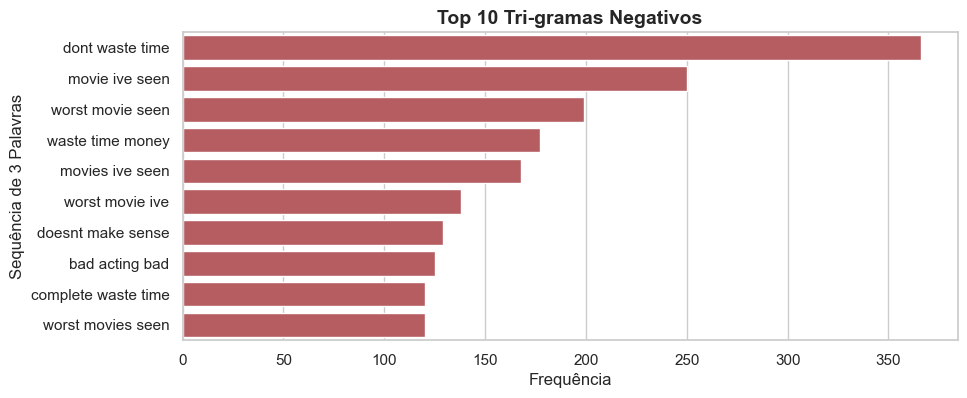

In [112]:
# Pegas as 3 palavras  mais ditas
print("Gráficos: Contexto Profundo (Tri-gramas)")

def plotar_trigramas(sentimento, titulo, cor):
    # Pegamos os textos do sentimento escolhido
    textos = df[df['sentimento'] == sentimento]['review_limpa']

    # agrupar de 3 em 3 palavras
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english', max_features=10).fit(textos)

    # Contando as frequências
    bag_of_words = vec.transform(textos)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    # Desenhando o Gráfico
    plt.figure(figsize=(10, 4))
    sns.barplot(x='Frequência', y='Tri-grama', data=pd.DataFrame(words_freq, columns=['Tri-grama', 'Frequência']), color=cor)
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.ylabel('Sequência de 3 Palavras')
    plt.show()

# Gerando os dois gráficos
plotar_trigramas('positive', 'Top 10 Tri-gramas Positivos', '#55A868')
plotar_trigramas('negative', 'Top 10 Tri-gramas Negativos', '#C44E52')

# PRE PROCESSAMENTO

In [113]:
print("A preparar a matemática para a IA...\n")

# 1. ALVO: Converter os sentimentos para números (a IA não lê texto)
df['sentimento_num'] = df['sentimento'].map({'positive': 1, 'negative': 0})
X = df['review_limpa']
y = df['sentimento_num']

# 2. DIVISÃO: 60% Treino, 20% Validação e 20% Teste
# O 'stratify' garante a mesma proporção de críticas boas/más em todas as partes
X_treino_val, X_teste, y_treino_val, y_teste = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_treino, X_val, y_treino, y_val = train_test_split(X_treino_val, y_treino_val, test_size=0.25, random_state=42, stratify=y_treino_val)

print(f"Divisão exata: Treino ({len(X_treino)}) | Validação ({len(X_val)}) | Teste ({len(X_teste)})")

# 3. VETORIZAÇÃO: Criar matriz com peso estatístico das 5000 palavras principais
vetorizador = TfidfVectorizer(max_features=5000, stop_words='english')

# .fit_transform() no treino: a IA aprende o vocabulário e converte os dados
X_treino_tfidf = vetorizador.fit_transform(X_treino)

# .transform() na validação/teste: apenas converte para evitar fugas de dados (data leakage)
X_val_tfidf = vetorizador.transform(X_val)
X_teste_tfidf = vetorizador.transform(X_teste)

print(f"Matriz TF-IDF pronta com as {X_treino_tfidf.shape[1]} palavras vitais.")

A preparar a matemática para a IA...

Divisão exata: Treino (29748) | Validação (9917) | Teste (9917)
Matriz TF-IDF pronta com as 5000 palavras vitais.


# TREINANDO OS 3 MODELOS

In [114]:
print("Treinando os modelos e rodando K-Fold (k=3)...")

modelos = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'LinearSVC': LinearSVC(dual=False)
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
resultados = []

for nome, modelo in modelos.items():
    scores = cross_validate(modelo, X_treino_tfidf, y_treino, cv=skf, scoring=metricas)
    resultados.append({
        'Classificador': nome,
        'Acurácia': scores['test_accuracy'].mean(),
        'Precisão': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1'].mean(),
        'AUC-ROC': scores['test_roc_auc'].mean()
    })

tabela_resultados = pd.DataFrame(resultados)
print("\n--- TABELA COMPARATIVA ---")
display(tabela_resultados.round(4))

Treinando os modelos e rodando K-Fold (k=3)...

--- TABELA COMPARATIVA ---


,Classificador,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
0,MultinomialNB,0.8523,0.8491,0.8582,0.8536,0.9288
1,LogisticRegression,0.8807,0.8710,0.8949,0.8828,0.9503
2,LinearSVC,0.8706,0.8655,0.8787,0.8720,0.9426


# VALIDADNO OS 3 MOLEDEMOS

Avaliando Acertos e Erros (Matrizes de Confusão)...


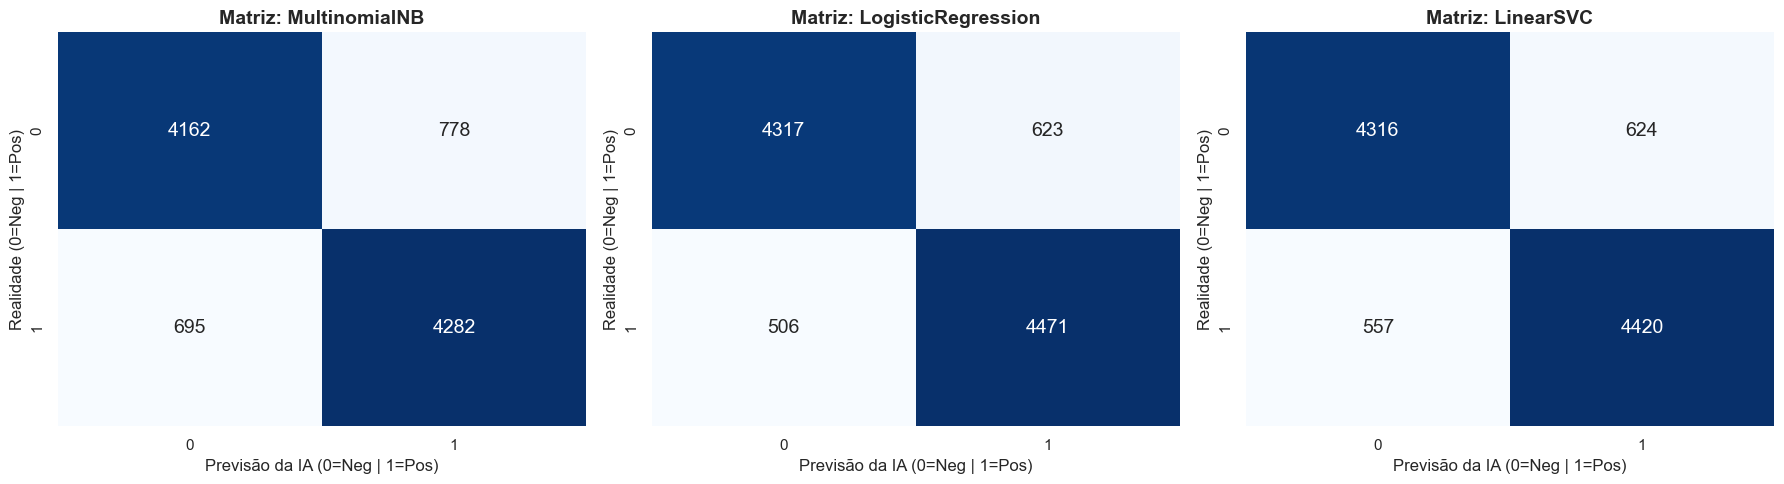

In [115]:
print("Avaliando Acertos e Erros (Matrizes de Confusão)...")

for nome, modelo in modelos.items():
    modelo.fit(X_treino_tfidf, y_treino)

plt.figure(figsize=(18, 5))
for i, (nome, modelo) in enumerate(modelos.items(), 1):
    y_pred = modelo.predict(X_val_tfidf)
    cm = confusion_matrix(y_val, y_pred)

    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
    plt.title(f'Matriz: {nome}', fontweight='bold', fontsize=14)
    plt.xlabel('Previsão da IA (0=Neg | 1=Pos)')
    plt.ylabel('Realidade (0=Neg | 1=Pos)')
plt.tight_layout()
plt.show()

 Gráfico de Eficiência: Curvas ROC...


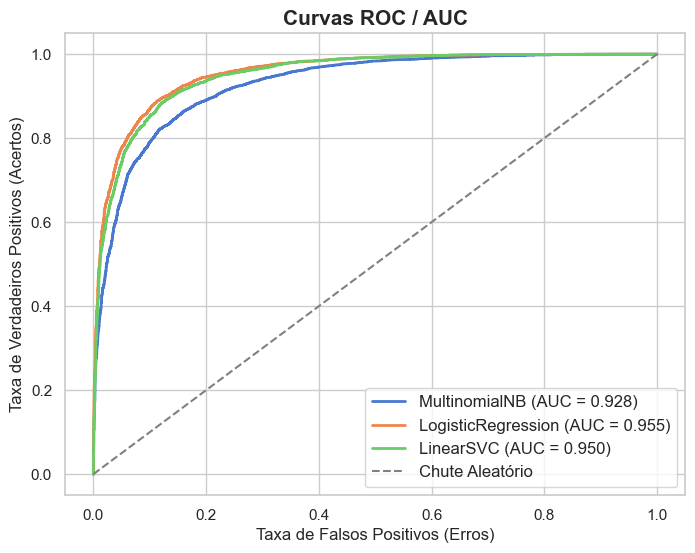

In [116]:
print(" Gráfico de Eficiência: Curvas ROC...")

plt.figure(figsize=(8, 6))
for nome, modelo in modelos.items():
    if hasattr(modelo, "predict_proba"):
        probabilidades = modelo.predict_proba(X_val_tfidf)[:, 1]
    else:
        probabilidades = modelo.decision_function(X_val_tfidf)
    fpr, tpr, _ = roc_curve(y_val, probabilidades)
    plt.plot(fpr, tpr, lw=2, label=f'{nome} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chute Aleatório')
plt.title('Curvas ROC / AUC', fontweight='bold', fontsize=15)
plt.xlabel('Taxa de Falsos Positivos (Erros)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Acertos)', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.show()

# ANALISANDO A MELHOR IA E QUAL FOI SEUS PESSOS COM BASE NAS PALAVRAS

Extraindo o impacto das palavras na Regressão Logística...



/var/folders/k9/4cr0z6g52v57c8vbddmtf_9w0000gn/T/ipykernel_9220/1568411408.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Palavra', data=top_palavras, palette=cores)


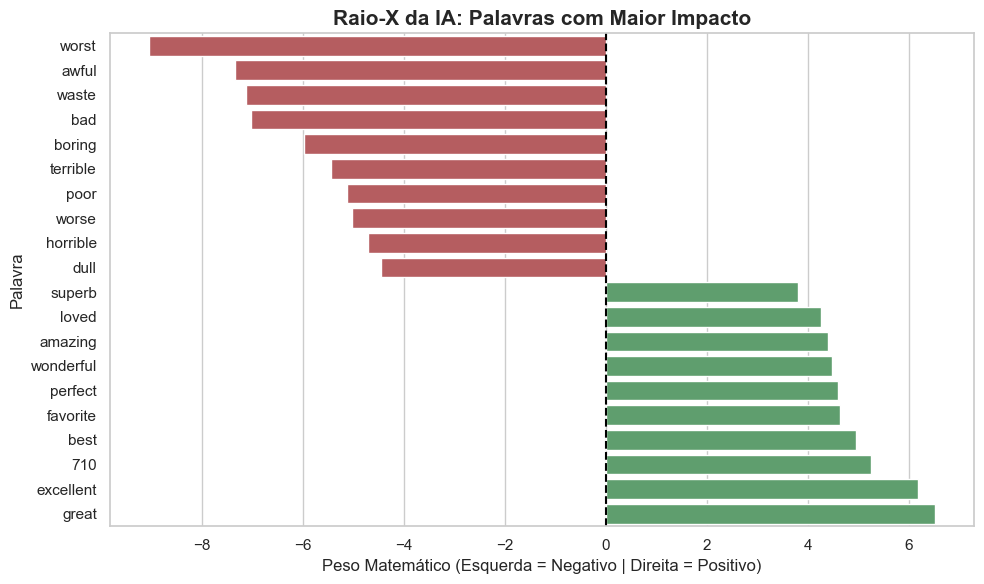

In [117]:
print("Extraindo o impacto das palavras na Regressão Logística...\n")

modelo_escolhido = modelos['LogisticRegression']
palavras = vetorizador.get_feature_names_out()
pesos = modelo_escolhido.coef_[0]

df_pesos = pd.DataFrame({'Palavra': palavras, 'Peso': pesos})
top_positivas = df_pesos.sort_values(by='Peso', ascending=False).head(10)
top_negativas = df_pesos.sort_values(by='Peso', ascending=True).head(10)
top_palavras = pd.concat([top_positivas, top_negativas]).sort_values(by='Peso')

plt.figure(figsize=(10, 6))
cores = ['#C44E52' if x < 0 else '#55A868' for x in top_palavras['Peso']]
sns.barplot(x='Peso', y='Palavra', data=top_palavras, palette=cores)
plt.title('Raio-X da IA: Palavras com Maior Impacto', fontsize=15, fontweight='bold')
plt.xlabel('Peso Matemático (Esquerda = Negativo | Direita = Positivo)')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
plt.tight_layout()
plt.show()


In [118]:
# Erros, qual foi a onde ela penou para saber o resultado
y_pred_val = modelo_escolhido.predict(X_val_tfidf)
df_erros = pd.DataFrame({'Texto': X_val, 'Real': y_val, 'Previsto': y_pred_val})

falso_positivo = df_erros[(df_erros['Real'] == 0) & (df_erros['Previsto'] == 1)]
falso_negativo = df_erros[(df_erros['Real'] == 1) & (df_erros['Previsto'] == 0)]

print("\n--- EXEMPLOS DE ERROS---")
if not falso_positivo.empty:
    print(f"\n FALSO POSITIVO (A review era Ruim, mas a IA achou Boa):\n{falso_positivo.iloc[0]['Texto'][:400]}...")

if not falso_negativo.empty:
    print(f"\nFALSO NEGATIVO (A review era Boa, mas a IA achou Ruim):\n{falso_negativo.iloc[0]['Texto'][:400]}...")


--- EXEMPLOS DE ERROS---

 FALSO POSITIVO (A review era Ruim, mas a IA achou Boa):
does anyone think that this show actually helps some people or does it only anger the people who watch it when i am flipping through the channels and come upon this show i half to watch out of morbid curiosity i understand that pat roberson is not all together what i do not know is if his viewers are like him or if they are good people and think they will have a better life if they listening to wh...

FALSO NEGATIVO (A review era Boa, mas a IA achou Ruim):
being a giant monster fan me seeing yeti was an absolute must especially after hearing so much about it thanks to the good ol bootleg market i was able to find a copy pretty easily and was happily surprised upon watching that this flick was actually dare i say decent  decent for what it is actually namely a cheesy giantmonster flick it kicks in pretty quickly as yeti is found pretty much immediate...


In [119]:
print("=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===\n")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predição no conjunto de teste (dados que o modelo NUNCA viu)
y_pred_teste = modelo_final.predict(X_teste_tfidf)

# Métricas finais
print(f"Acurácia:  {accuracy_score(y_teste, y_pred_teste):.4f}")
print(f"Precisão:  {precision_score(y_teste, y_pred_teste):.4f}")
print(f"Recall:    {recall_score(y_teste, y_pred_teste):.4f}")
print(f"F1-Score:  {f1_score(y_teste, y_pred_teste):.4f}")

print("\n--- Relatório Completo ---")
print(classification_report(y_teste, y_pred_teste, target_names=['Negativo', 'Positivo']))

=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===

Acurácia:  0.5343
Precisão:  0.5393
Recall:    0.4951
F1-Score:  0.5162

--- Relatório Completo ---
              precision    recall  f1-score   support

    Negativo       0.53      0.57      0.55      4940
    Positivo       0.54      0.50      0.52      4977

    accuracy                           0.53      9917
   macro avg       0.53      0.53      0.53      9917
weighted avg       0.53      0.53      0.53      9917



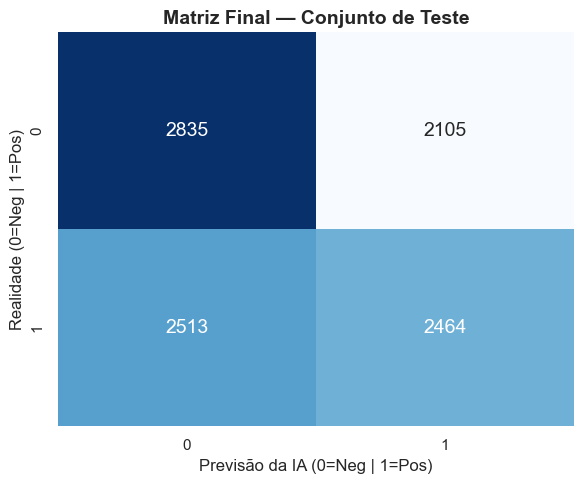

In [120]:
# Matriz de confusão no teste
cm_final = confusion_matrix(y_teste, y_pred_teste)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title('Matriz Final — Conjunto de Teste', fontweight='bold', fontsize=14)
plt.xlabel('Previsão da IA (0=Neg | 1=Pos)')
plt.ylabel('Realidade (0=Neg | 1=Pos)')
plt.tight_layout()
plt.show()

In [121]:
import joblib
import os

# cria a pasta model se não existir
os.makedirs("model", exist_ok=True)

# treina o modelo vencedor
modelo_final = LogisticRegression(max_iter=1000)
modelo_final.fit(X_treino_tfidf, y_treino)

# salva modelo e vetorizador
joblib.dump(modelo_final, "model/modelo_final.pkl")
joblib.dump(vetorizador, "model/vetorizador.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
